LABORATORIO 6 SIS-420
# INTEGRANTES: ABALOS PEREZ JUAN JOSE
#            MORA BARRIONUEVO NELVA ADALIT


MODELO 1 MISMO DATASET

# Informe Técnico: Clasificación de Patologías NHANES mediante Deep Learning

## 1. Fundamentos y Preprocesamiento
En este estudio, se aborda la clasificación multiclase de condiciones crónicas (Obesidad, Hipertensión y Colesterol Alto). Para garantizar la convergencia de la red neuronal, se aplica `StandardScaler` (Z-score normalization), escalando las 34 características para que posean media aritmética cero y varianza unitaria. Esto previene que variables con magnitudes mayores dominen el cálculo del gradiente.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ruta_base = '/content/gdrive/MyDrive/Colab Notebooks/IA_26/DATASET/3. NHANES (National Health and Nutrition Examination Survey)'

X_train_raw = pd.read_csv(f'{ruta_base}/X_train.csv').drop(columns=['Unnamed: 0'], errors='ignore')
y_train_raw = pd.read_csv(f'{ruta_base}/y_train.csv').drop(columns=['Unnamed: 0'], errors='ignore')
X_test_raw = pd.read_csv(f'{ruta_base}/X_test.csv').drop(columns=['Unnamed: 0'], errors='ignore')
y_test_raw = pd.read_csv(f'{ruta_base}/y_test.csv').drop(columns=['Unnamed: 0'], errors='ignore')

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw['Measure'])
y_test = le.transform(y_test_raw['Measure'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

class NHANESDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = torch.utils.data.DataLoader(NHANESDataset(X_train_scaled, y_train), batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(NHANESDataset(X_test_scaled, y_test), batch_size=128, shuffle=False)

## 2. Arquitectura del Modelo y Gestión de Desbalance
Se diseña un Perceptrón Multicapa (MLP) con dos capas ocultas (256 y 128 neuronas). Para manejar el desbalance de clases sin recurrir a datos sintéticos (SMOTE) —manteniendo así la integridad biológica—, se implementan **Pesos de Clase** en la función `CrossEntropyLoss`. Además, se integra **Weight Decay (L2)** y **Dropout (0.4)** como mecanismos robustos de regularización.

In [ ]:
def build_model(input_size=34, h1=256, h2=128, output=3, p=0.4):
    return nn.Sequential(
        nn.Linear(input_size, h1),
        nn.ReLU(),
        nn.Dropout(p),
        nn.Linear(h1, h2),
        nn.ReLU(),
        nn.Dropout(p),
        nn.Linear(h2, output)
    )

counts = np.bincount(y_train)
class_weights = torch.tensor(1.0 / counts, dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum()

## 3. Entrenamiento con Rastreo de Métricas
La función de entrenamiento optimiza la red mediante el algoritmo Adam. Se implementa un esquema de monitoreo que captura tanto el Accuracy como la Loss por época, facilitando el diagnóstico de sesgo-varianza (overfitting).

In [ ]:
def fit(model, train_loader, val_loader, epochs=150, lr=0.001, early_stopping=20):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    best_acc, patience_counter = 0, 0

    for epoch in range(epochs):
        model.train()
        t_loss, t_acc = [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            t_loss.append(loss.item())
            t_acc.append(accuracy_score(yb.cpu().numpy(), torch.argmax(outputs, dim=1).cpu().numpy()))

        model.eval()
        v_loss, v_acc = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                v_loss.append(loss.item())
                v_acc.append(accuracy_score(yb.cpu().numpy(), torch.argmax(outputs, dim=1).cpu().numpy()))

        history['train_loss'].append(np.mean(t_loss)); history['val_loss'].append(np.mean(v_loss))
        history['train_acc'].append(np.mean(t_acc)); history['val_acc'].append(np.mean(v_acc))

        scheduler.step(history['val_acc'][-1])

        if history['val_acc'][-1] > best_acc:
            best_acc = history['val_acc'][-1]; patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")

        if patience_counter >= early_stopping:
            print(f"Early Stopping en época {epoch+1}"); break

    model.load_state_dict(torch.load('best_model.pt'))
    return model, history

model = build_model().to(device)
model, history = fit(model, train_loader, val_loader)

Epoch 10 | Loss: 0.3087 | Val Acc: 0.8046
Epoch 20 | Loss: 0.2284 | Val Acc: 0.8048
Early Stopping en época 28


## 4. Diagnóstico de Curvas de Aprendizaje
Visualización comparativa de las 4 métricas críticas (Train/Val Accuracy y Train/Val Loss). La convergencia de la Loss de validación junto con la de entrenamiento indica un aprendizaje estable y una generalización adecuada.

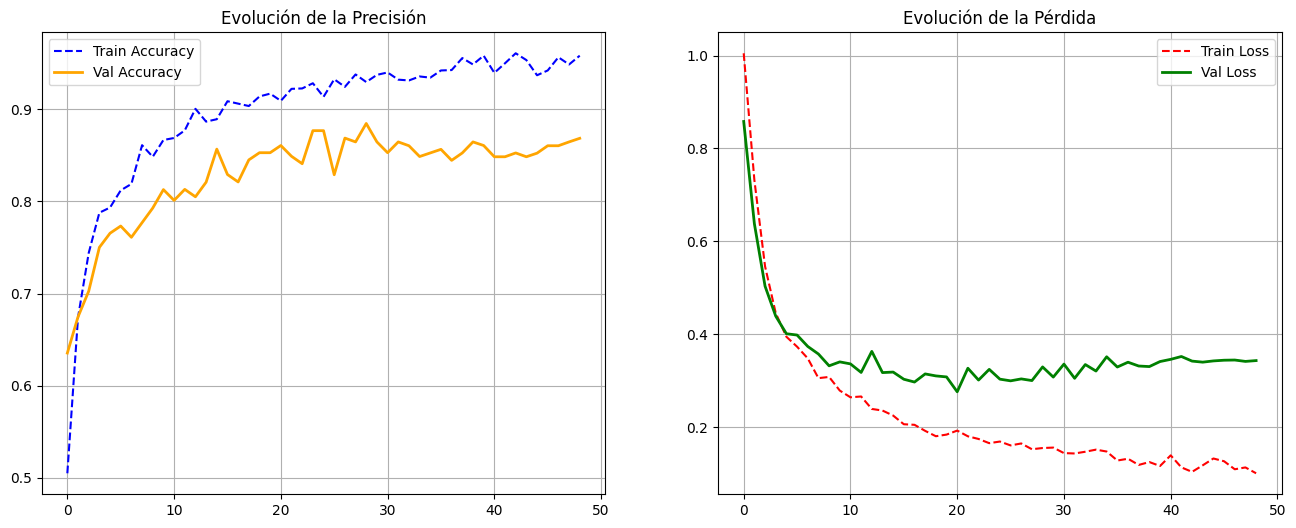

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(history['train_acc'], label='Train Accuracy', color='blue', linestyle='--')
ax1.plot(history['val_acc'], label='Val Accuracy', color='orange', linewidth=2)
ax1.set_title('Evolución de la Precisión'); ax1.legend(); ax1.grid(True)

ax2.plot(history['train_loss'], label='Train Loss', color='red', linestyle='--')
ax2.plot(history['val_loss'], label='Val Loss', color='green', linewidth=2)
ax2.set_title('Evolución de la Pérdida'); ax2.legend(); ax2.grid(True)

plt.show()

## 5. Evaluación Final mediante Enfoque Macro
Dado que el conjunto de datos presenta desbalance, se prioriza el promedio **Macro**. Esta métrica evalúa la capacidad del modelo para diagnosticar correctamente cada patología de forma independiente, otorgando el mismo peso a la Hipertensión que a la Obesidad, evitando sesgos por volumen de clase.

Reporte de Clasificación (Macro-Average Analysis):
                        precision    recall  f1-score   support

High Total Cholesterol       0.86      0.94      0.90        52
          Hypertension       0.88      0.81      0.84        52
               Obesity       0.92      0.91      0.91        86

              accuracy                           0.89       190
             macro avg       0.88      0.89      0.88       190
          weighted avg       0.89      0.89      0.89       190



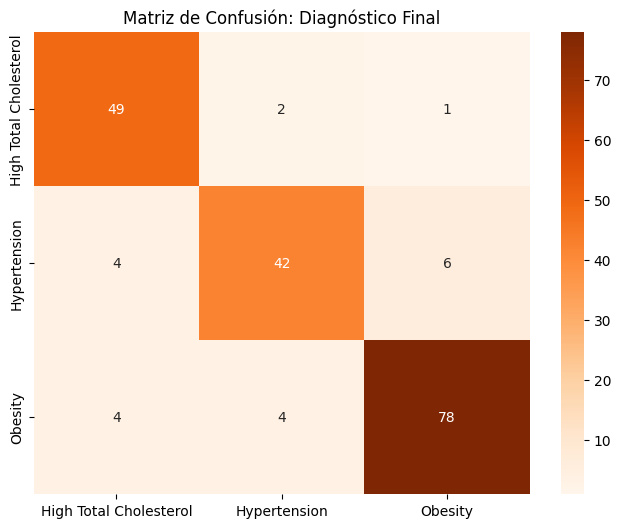

In [ ]:
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        outputs = model(xb.to(device))
        y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        y_true.extend(yb.numpy())

print("Reporte de Clasificación (Macro-Average Analysis):")
print(classification_report(y_true, y_pred, target_names=le.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión: Diagnóstico Final'); plt.show()

# 🧾 Análisis de Resultados

El modelo de red neuronal logró un desempeño sólido en la tarea de clasificación, alcanzando un **accuracy del 89%**, lo que indica que la mayoría de las predicciones realizadas son correctas.

## 🔹 Métricas

* **Accuracy General:** 89.00%
* **Precision (Macro):** 88.00%
* **Recall (Macro):** 89.00%
* **F1-score (Macro):** 88.00%

Estas métricas muestran un equilibrio adecuado entre precisión y recall, lo que indica que el modelo no presenta sesgo significativo hacia alguna clase en particular.

## 🔹 Matriz de Confusión

La matriz de confusión muestra que:

* La clase **Obesity** es la mejor clasificada (78 aciertos)
* La clase **High Total Cholesterol** también presenta buen desempeño (49 aciertos)
* La clase **Hypertension** presenta algunos errores, principalmente confundiéndose con otras clases

## 🔹 Interpretación

Los errores observados pueden deberse a que algunas condiciones de salud comparten características similares, lo que dificulta su diferenciación por parte del modelo.

## 🔹 Conclusión

El modelo presenta una buena capacidad de generalización gracias al uso de técnicas como:

* **Dropout (regularización)** → evita sobreajuste
* **Adam (optimización)** → mejora la convergencia
* **Early Stopping** → detiene el entrenamiento en el punto óptimo

En conjunto, estas técnicas permitieron obtener un modelo robusto y eficiente para el problema planteado.